# Aplicación del algoritmo de optimización de Colonia de Abejas (ABC) para la reducción de costos operativos en el problema de enrutamiento de vehículos en Perú

**Resumen**: El trabajo aborda la planificación ineficiente de rutas vehiculares en el Perú y su impacto en los costos operativos del transporte. El objetivo consiste en optimizar rutas de distribución considerando la distancia, tiempo y costo. Para ello, se adaptó un algoritmo de colonia de abejas artificiales que se comparó con un modelo de referencia  basado solo en distancia. La solución propuesta incorpora datos de viajes, demanda simulada y una evaluación logística completa.  Los resultados obtenidos mostraron una mejora moderada en la calidad de las rutas, demostrando la reducción de tiempo, distancia y costo operativo. Por ello, se concluye que el modelo adaptado ofrece una alternativa más realista y eficiente para la toma de decisiones logísticas.

- - -
- - - 

In [103]:
# Importamos las librerias necesarias para todo el notebook
import pandas as pd
import numpy as np
from scipy.spatial import distance_matrix
from utils import common
from algorithm import bee_colony
import random
import math
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')

random.seed(42)
np.random.seed(42)

## Implementación del Baseline Original (GitHub) para Artificial Bee Colony (ABC)
> **Nota:** Esta sección no reemplaza el algoritmo ABC mejorado. Únicamente inyecta métodos adicionales a la clase base `bee_colony.BeeColony` para permitir la ejecución del baseline original con el mismo dataset y problema, facilitando así la comparación de resultados.

### Inicialización y Configuración (Factory Method)
Método para crear una instancia de `BeeColony` configurada específicamente para correr el baseline original.

In [104]:
from algorithm import local_search, neighbor_operator
from tqdm import tqdm


def _create_original_github(cls, problem, **params):
    """
    Crea una instancia BeeColony configurada para ejecutar el baseline original.
    Uso:
        ABC_base = bee_colony.BeeColony.create_original_github(problem, n_epoch=200, ...)
    """
    alg = cls(problem)
    alg.set_params(**params)
    return alg

### Función de Costo: Cálculo de Distancia
Calcula el costo original sumando únicamente las distancias de los arcos recorridos, sin considerar tiempos ni costos operativos.

In [105]:
def _compute_solution_original_github(problem, solution):
    """
    Costo original del GitHub baseline: suma únicamente las distancias d_ij
    de los arcos recorridos. No incorpora tiempo ni costo operativo.
    """
    n = problem['n_locations']
    x = np.zeros((n, n), dtype=np.int32)
    for i, loc in enumerate(solution[:-1]):
        x[solution[i], solution[i + 1]] = 1
    return problem['dists'][x == 1].sum()

### Evaluación de Fitness con Penalizaciones
Calcula la aptitud de una solución. Penaliza fuertemente el exceso de demanda sobre la capacidad del vehículo.

In [106]:
def _fitness_original_github(problem, solution, alpha=0.5, betta=0.5):
    """
    Fitness original del repositorio GitHub:
        fitness = 1 / (c + alpha*q + betta*t)

    Donde:
    - c: distancia total original.
    - q: exceso máximo de demanda sobre la capacidad.
    - t: término de longitud de ruta; en el baseline se mantiene en 0.
    """
    c = bee_colony.BeeColony.compute_solution_original_github(problem, solution)
    demands = common.get_routes_demand(problem, solution)
    q = max(demands) - problem['capacity']
    t = 0
    return 1 / (c + alpha * q + betta * t)

### Probabilidad de Selección (Ruleta)
Calcula las probabilidades de selección proporcional al fitness, utilizadas por las abejas observadoras para elegir vecindarios.

In [107]:
def _pi_original_github(fitnesses):
    """
    Probabilidad p_i usada por las abejas observadoras en el baseline:
        p_i = fitness_i / suma_fitness
    """
    f_sum = sum(fitnesses)
    if f_sum == 0:
        return [1 / len(fitnesses) for _ in fitnesses]
    return [f / f_sum for f in fitnesses]

### Ciclo Principal del Algoritmo (Solve Baseline)
Copia funcional del algoritmo original. Contiene las tres fases clásicas del ABC:
* **Fase 1:** Abejas Empleadas (Búsqueda local).
* **Fase 2:** Abejas Observadoras (Exploración basada en probabilidad).
* **Fase 3:** Abejas Exploradoras (Reemplazo de soluciones estancadas).

In [108]:
def _solve_original_github(self, alpha=0.2, betta=0.2, delta=0.01, gen_alpha=1, gen_betta=0.5):
    """
    Copia funcional del solve() original del GitHub baseline.
    Mantiene la esencia base:
    - genera soluciones iniciales,
    - evalúa con fitness basado en distancia,
    - usa búsqueda local,
    - usa ruleta p_i para observadoras,
    - reemplaza soluciones estancadas,
    - ajusta alpha según capacidad.
    """

    solutions = [common.generate_solution(self.problem,
                                          alpha=gen_alpha,
                                          betta=gen_betta,
                                          patience=100)
                 for _ in range(self.n_initials)]

    fitnesses = [self.fitness_original_github(self.problem, solution, alpha=alpha, betta=betta)
                 for solution in solutions]
    counters = np.zeros(self.n_initials, dtype=np.int32)

    alg = local_search.LocalSearch(self.problem)
    nn_operator = neighbor_operator.NeighborOperator()

    for _ in tqdm(range(self.n_epoch), total=self.n_epoch, desc="ABC GitHub Original"):

        # FASE 1: ABEJAS EMPLEADAS
        for i, solution in enumerate(solutions):
            alg.set_params(solution, n_iter=12)
            neighbor, _ = alg.solve(only_feasible=True)
            nfitness = self.fitness_original_github(self.problem, neighbor, alpha=alpha, betta=betta)

            if nfitness > fitnesses[i]:
                solutions[i] = neighbor
                fitnesses[i] = nfitness
                counters[i] = 0
            else:
                counters[i] += 1

        # FASE 2: ABEJAS OBSERVADORAS
        neighborhood = [[] for _ in range(self.n_initials)]
        probs = self.pi_original_github(fitnesses)

        for _ in range(self.n_onlookers):
            roulette = np.random.choice(range(len(probs)), p=probs)
            solution = solutions[roulette]
            neighbor = nn_operator.random_operator(solution, patience=20)
            neighborhood[roulette].append(neighbor)

            # Misma lógica del GitHub original:
            # si el vecino cumple capacidad, también puede evaluarse en otros vecindarios.
            for i, neighs in enumerate(neighborhood):
                if common.check_capacity_criteria(self.problem, neighbor):
                    neighs.append(neighbor)

        for i, neighbors in enumerate(neighborhood):
            if neighbors:
                fits = [self.fitness_original_github(self.problem, neighbor, alpha=alpha, betta=betta)
                        for neighbor in neighbors]
                if max(fits) > fitnesses[i]:
                    solutions[i] = neighbors[int(np.argmax(fits))]
                    fitnesses[i] = max(fits)
                    counters[i] = 0
                else:
                    counters[i] += 1

        # FASE 3: ABEJAS EXPLORADORAS
        for i, solution in enumerate(solutions):
            if counters[i] == self.search_limit:
                solutions[i] = nn_operator.random_operator(solution, patience=10)

        # Ajuste dinámico de alpha según factibilidad de capacidad.
        criteria = [common.check_capacity_criteria(self.problem, solution)
                    for solution in solutions]
        if sum(criteria) > (len(criteria) / 2):
            alpha -= delta
        else:
            alpha += delta

        self.history.append(1 / np.mean(fitnesses))
        self.history_alpha.append(alpha)

    # Retornar la mejor solución factible.
    while len(solutions) > 0:
        best_idx = int(np.argmax(fitnesses))
        solution = solutions[best_idx]
        if common.check_solution(self.problem, solution):
            break
        del solutions[best_idx]
        del fitnesses[best_idx]

    return solution

### Inyección de Métodos (Monkey Patching) a la Clase Base
Asignación dinámica de las funciones anteriores a la clase `bee_colony.BeeColony` utilizando `classmethod`, `staticmethod` y asignación directa.

In [109]:
bee_colony.BeeColony.create_original_github = classmethod(_create_original_github)
bee_colony.BeeColony.compute_solution_original_github = staticmethod(_compute_solution_original_github)
bee_colony.BeeColony.fitness_original_github = staticmethod(_fitness_original_github)
bee_colony.BeeColony.pi_original_github = staticmethod(_pi_original_github)
bee_colony.BeeColony.solve_original_github = _solve_original_github
bee_colony.BeeColony.solve_baseline_original = _solve_original_github

print("Métodos baseline original agregados a bee_colony.BeeColony correctamente.")

Métodos baseline original agregados a bee_colony.BeeColony correctamente.


- - -

## Limpieza de datos y declaración de constantes
> **Nota:** Esta sección busca dar limpieza al dataset inicial de `uber_peru_2010.csv` y solo usar las variables predictivas que se consideraron pertinentes para el ejecicio.

In [110]:
#Declaramos constantes para su uso posterior
PrecioGasolinaPorKM     = 1.20
CostoPorTiempoEjecucion = 1.00
VelocidadMediaDefault   = 20.0

In [111]:
# Cargamos el dataset de uber
df = pd.read_csv("uber_peru_2010.csv", delimiter=';')
print(df.shape)
df.head()

(23111, 28)


,journey_id,user_id,driver_id,taxi_id,icon,start_type,start_at,start_lat,start_lon,end_at,...,price_distance,price_duration,distance,duration,cost,cost_distance,cost_duration,source,driver_score,rider_score
0,23a1406fc6a11d866e3c82f22eed4d4c,0e9af5bbf1edfe591b54ecdfd7e91e26,583949a89a9ee17d19e3ca4f137b6b4c,b12f4f09c783e29fe0d0ea624530db56,executive,asap,16/11/2010 16:44,"-12,13983536","-77,02355957",16/11/2010 17:29,...,3626.0,195.0,11331.0,234.0,0.0,0.0,0.0,iPhone,5.0,5.0
1,dd2af4715d0dc16eded53afc0e243577,a553c46e3a22fb9c326aeb3d72b3334e,NaN,NaN,executive,asap,01/06/2010 0:34,"-12,13874817","-76,99536133",01/06/2010 0:37,...,NaN,NaN,0.0,0.0,0.0,NaN,NaN,iPhone,NaN,NaN
2,dd91e131888064bf7df3ce08f3d4b4ad,a553c46e3a22fb9c326aeb3d72b3334e,NaN,NaN,executive,asap,31/05/2010 5:01,"-12,12453079","-77,02780151",31/05/2010 5:04,...,NaN,NaN,0.0,0.0,0.0,NaN,NaN,iPhone,NaN,NaN
3,dd2af4715d0dc16eded53afc0e2466d0,a553c46e3a22fb9c326aeb3d72b3334e,NaN,NaN,executive,asap,01/06/2010 0:29,"-12,13885117","-76,99530029",01/06/2010 0:32,...,NaN,NaN,0.0,0.0,0.0,NaN,NaN,iPhone,NaN,NaN
4,85b7eabcf5d84e42dc7629b7d27781af,56772d544fdfa589a020a1ff894a86f7,d665fb9f75ef5d9cd0fd89479380ba78,0accdd3aa5a322f4129fa20b53278c69,executive,reserved,11/09/2010 23:55,"-12,08995438","-76,92626953",12/09/2010 1:07,...,7665.0,562.0,30270.0,715.0,6173.0,5756.0,417.0,iPhone,4.0,5.0


In [112]:
#Mantenemos columnas utiles para el modelo
columnas_mantener = ["start_at", "end_at", "start_lat", "start_lon", "end_lat", "end_lon", "distance"]
df = df[columnas_mantener].copy()

In [113]:
#Renombramos nuestras columnas
traduccion_columnas = {
    "start_at": "fecha_inicio",
    "end_at": "fecha_fin",
    "start_lat": "lat_inicio",
    "start_lon": "lon_inicio",
    "end_lat": "lat_fin",
    "end_lon": "lon_fin",
    "distance": "distancia"
}

df.rename(columns=traduccion_columnas, inplace=True)

In [114]:
#Cambiamos el tipo de dato a uno numérico
columna_lat_lon = ["lat_inicio", "lon_inicio", "lat_fin",  "lon_fin",]
df[columna_lat_lon] = df[columna_lat_lon].replace(',', '.', regex=True).apply(pd.to_numeric)

In [115]:
#Cambiamos el tipo de dato a fecha
df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio"], format="%d/%m/%Y %H:%M")
df["fecha_fin"] = pd.to_datetime(df["fecha_fin"], format="%d/%m/%Y %H:%M")

In [116]:
#Verificamos valores nulos
df.isna().sum() / len(df) * 100

fecha_inicio    0.000000
fecha_fin       1.194237
lat_inicio      0.000000
lon_inicio      0.000000
lat_fin         0.000000
lon_fin         0.000000
distancia       1.137986
dtype: float64

In [117]:
#Eliminamos los valores nulos en estas columnas
df.dropna(axis='index',subset=["fecha_fin", "distancia"], inplace=True)
df = df[df["distancia"] > 0]

df["distancia"] /= 1000 #Convertir a KM
df["duracion"] = (df["fecha_fin"] - df["fecha_inicio"]).dt.total_seconds() / 60
df["demanda"] = np.random.randint(1, 8, size=len(df)) #demanda aleatoria


In [118]:
#Verificamos valores finales
print(df.shape)
df.head()

(16604, 9)


,fecha_inicio,fecha_fin,lat_inicio,lon_inicio,lat_fin,lon_fin,distancia,duracion,demanda
0,2010-11-16 16:44:00,2010-11-16 17:29:00,-12.139835,-77.023560,-12.055370,-77.041321,11.331,45.0,7
4,2010-09-11 23:55:00,2010-09-12 01:07:00,-12.089954,-76.926270,-12.022232,-77.106384,30.270,72.0,4
5,2010-08-10 13:00:00,2010-08-10 14:26:00,-12.022419,-77.106506,-12.089802,-76.926086,29.080,86.0,5
6,2010-08-08 12:10:00,2010-08-08 12:48:00,-12.089958,-76.926209,-12.021523,-77.106232,27.230,38.0,7
7,2010-05-16 03:58:00,2010-05-16 04:40:00,-12.113472,-77.043854,-12.091087,-76.922668,17.247,42.0,3


- - - 


## Optimización de Rutas

### Inicialización de Parámetros y Muestreo de Datos
Para garantizar la validez del experimento y evitar sesgos por datos duplicados, se extrae una muestra aleatoria del conjunto de clientes. La cantidad de vehículos necesarios se calcula dinámicamente en función de la demanda total y la capacidad máxima permitida por unidad.

In [119]:
# Definición de restricciones operativas
limite_superior = 100 
capacidad_camion = 100

# Muestreo estocástico de clientes
n_clientes = min(random.randint(51, limite_superior), len(df))
df_muestra = df.sample(n=n_clientes, random_state=42) # random_state recomendado para reproducibilidad

# Cálculo de la demanda agregada y dimensionamiento de la flota
demanda_total = df_muestra['demanda'].sum()
n_camiones = math.ceil(demanda_total / capacidad_camion) + 1

### Cálculo de Matrices Espacio-Temporales y Función de Costos
Se construye la matriz de adyacencia espacial combinando las coordenadas del depósito y de los clientes. Posteriormente, se formulan las matrices de distancias (en kilómetros) y de tiempos de tránsito.

El modelo propuesto introduce una matriz de costos operativos, calculada mediante la siguiente función objetivo para cada arco $(i, j)$:

$$o_{ij} = c_f \cdot d_{ij} + c_t \cdot t_{ij}$$

Donde:
*   $o_{ij}$: Costo operativo total del nodo $i$ al $j$.
*   $c_f$: Precio del combustible por kilómetro.
*   $d_{ij}$: Distancia entre los nodos $i$ y $j$.
*   $c_t$: Costo asociado al tiempo de ejecución (laboral/operativo).
*   $t_{ij}$: Tiempo estimado de tránsito entre los nodos $i$ y $j$.

In [120]:
# Consolidación de coordenadas (Depósito + Nodos de clientes)
coordenadas_deposito = df_muestra[['lat_inicio', 'lon_inicio']].iloc[0]
coordenadas_clientes = df_muestra[['lat_fin', 'lon_fin']]
localizaciones = np.vstack([coordenadas_deposito, coordenadas_clientes])

# Transformación de la matriz espacial (grados a kilómetros usando el factor de conversión)
matriz_distancias_km = distance_matrix(localizaciones, localizaciones) * 111.139

# Estimación empírica de la velocidad promedio del conjunto de datos
duracion_horas = df_muestra['duracion'] / 60.0
velocidades_km_h = df_muestra['distancia'] / duracion_horas
velocidades_validas = velocidades_km_h[velocidades_km_h.between(5, 120, inclusive='neither')]

velocidad_promedio = np.mean(velocidades_validas) if len(velocidades_validas) > 0 else VelocidadMediaDefault

# Generación de la Matriz de Tiempos
matriz_tiempos = matriz_distancias_km / velocidad_promedio
np.fill_diagonal(matriz_tiempos, 0.0)

# Cálculo de la Matriz de Costos Operativos (Ecuación integral)
matriz_costos_operativos = (PrecioGasolinaPorKM * matriz_distancias_km) + (CostoPorTiempoEjecucion * matriz_tiempos)

### Estructuración del Espacio del Problema
Se consolida la topología de la red, la demanda de los nodos y las restricciones de capacidad en un diccionario unificado, el cual servirá como espacio de búsqueda para las heurísticas del algoritmo ABC.

In [121]:
# Estructura de datos unificada para el optimizador
problema = {
    'n_trucks': n_camiones,
    'optimal': 0,
    'capacity': capacidad_camion,
    'n_locations': int(n_clientes + 1),
    'depot_i': 0,
    'demands': [0.0] + df_muestra['demanda'].tolist(),
    'locations': localizaciones,
    'dists': matriz_distancias_km,
    'times': matriz_tiempos,
    'op_costs': matriz_costos_operativos
}

### Fase de Optimización: Modelo ABC Propuesto
Se ejecuta la metaheurística de Colonia de Abejas Artificiales (ABC) adaptada para minimizar la matriz de costos operativos, configurando los hiperparámetros de búsqueda, exploración y explotación.

In [123]:
print("Iniciando fase de optimización algorítmica (Modelo ABC Propuesto)...")

# Instanciación y configuración de hiperparámetros
ABC = bee_colony.BeeColony(problema)
ABC.set_params(
    n_epoch=200,
    n_initials=30,
    n_onlookers=20,
    search_limit=50
)

# Resolución de la función objetivo
abc_solution = ABC.solve(
    alpha=0.1,
    delta=0.01,
    gen_alpha=0.01,
    gen_betta=25
)

# Cómputo del costo integral de la ruta óptima hallada
costo_final = common.compute_solution(problema, abc_solution)

Iniciando fase de optimización algorítmica (Modelo ABC Propuesto)...


Optimizando Rutas: 100%|██████████| 200/200 [01:14<00:00,  2.68it/s]


### Fase de Control: Modelo Baseline (Heurística de Distancia)
Con fines comparativos, se ejecuta la versión original del algoritmo. Este modelo optimiza las rutas minimizando exclusivamente la matriz de distancias, omitiendo variables temporales en su función objetivo.

In [124]:
print("Iniciando ejecución del modelo de control (ABC Baseline)...")

# Hiperparámetros de control (idénticos para garantizar paridad en la evaluación)
ABC_BASELINE_PARAMS = {
    "n_epoch": 200,
    "n_initials": 30,
    "n_onlookers": 20,
    "search_limit": 50
}

SOLVE_BASELINE_PARAMS = {
    "alpha": 0.1,
    "delta": 0.01,
    "gen_alpha": 0.01,
    "gen_betta": 25
}

# Ejecución del solver original
ABC_baseline = bee_colony.BeeColony.create_original_github(problema, **ABC_BASELINE_PARAMS)
abc_solution_baseline = ABC_baseline.solve_original_github(**SOLVE_BASELINE_PARAMS)

# Evaluación del modelo base
costo_distancia_baseline = ABC_baseline.compute_solution_original_github(problema, abc_solution_baseline)
costo_metodologia_baseline = common.compute_solution(problema, abc_solution_baseline)

Iniciando ejecución del modelo de control (ABC Baseline)...


ABC GitHub Original: 100%|██████████| 200/200 [01:09<00:00,  2.90it/s]


### Análisis Comparativo de Resultados
Se validan las restricciones lógicas (cumplimiento de capacidades máximas por unidad) y se realiza la comparativa financiera entre el modelo heurístico estándar y el modelo integral propuesto.

In [125]:
print("\n" + "="*80)
print(" "*25 + "REPORTE DE OPTIMIZACIÓN" + " "*25)
print("="*80 + "\n")

# Reporte de Métricas: Modelo Baseline
print("MÉTRICAS DEL MODELO BASELINE (Control por Distancia):")
print(f"▸ Factibilidad estructural (Capacidad respetada): {common.check_solution(problema, abc_solution_baseline, verbose=False)}")
print(f"▸ Función objetivo original minimizada:         {costo_distancia_baseline:.2f} unidades de distancia")
print(f"▸ Costo proyectado bajo metodología actual:     S/. {costo_metodologia_baseline:.2f}")
print(f"▸ Distribución de demanda por ruta:             {common.get_routes_demand(problema, abc_solution_baseline)}")

print("\n" + "-"*80 + "\n")

# Reporte de Métricas: Modelo Propuesto
print("MÉTRICAS DEL MODELO PROPUESTO (Control Integral de Costos):")
print(f"▸ Factibilidad estructural (Capacidad respetada): {common.check_solution(problema, abc_solution, verbose=False)}")
print(f"▸ Costo Operativo Total Optimizado:             S/. {costo_final:.2f}")
print(f"▸ Distribución de demanda por ruta:             {common.get_routes_demand(problema, abc_solution)}")
print("\n" + "="*80)


                         REPORTE DE OPTIMIZACIÓN                         

MÉTRICAS DEL MODELO BASELINE (Control por Distancia):
▸ Factibilidad estructural (Capacidad respetada): True
▸ Función objetivo original minimizada:         19717.79 unidades de distancia
▸ Costo proyectado bajo metodología actual:     S/. 46291.91
▸ Distribución de demanda por ruta:             [82, 74, 82, 34, 91]

--------------------------------------------------------------------------------

MÉTRICAS DEL MODELO PROPUESTO (Control Integral de Costos):
▸ Factibilidad estructural (Capacidad respetada): True
▸ Costo Operativo Total Optimizado:             S/. 46308.16
▸ Distribución de demanda por ruta:             [87, 73, 87, 61, 55]



# Sección de gráficas comparativas:

In [ ]:
def sumar_matriz_por_solucion(problem, solution, matriz_key):
    """
    Suma una matriz del problema siguiendo el orden de una solución.
    Sirve para distancia, tiempo y costo operativo.
    """
    matriz = problem.get(matriz_key, None)

    if matriz is None:
        return np.nan

    solution = list(map(int, solution))
    total = 0.0

    for i in range(len(solution) - 1):
        origen = solution[i]
        destino = solution[i + 1]
        total += float(matriz[origen][destino])

    return total


def obtener_metricas_solucion(problem, solution, nombre_modelo):
    """
    Calcula métricas comparables para cualquier solución:
    ABC Mejorado o ABC Baseline.
    """
    demandas_ruta = common.get_routes_demand(problem, solution)
    demandas_ruta = [float(d) for d in demandas_ruta]

    capacidad = problem["capacity"]
    excesos = [max(0, d - capacidad) for d in demandas_ruta]

    metricas = {
        "modelo": nombre_modelo,
        "factible": common.check_solution(problem, solution, verbose=False),
        "objetivo_metodologia_actual": common.compute_solution(problem, solution),
        "distancia_total": sumar_matriz_por_solucion(problem, solution, "dists"),
        "tiempo_total": sumar_matriz_por_solucion(problem, solution, "times"),
        "costo_operativo_total": sumar_matriz_por_solucion(problem, solution, "op_costs"),
        "demanda_maxima_ruta": max(demandas_ruta),
        "exceso_total_capacidad": sum(excesos),
        "numero_rutas": len(demandas_ruta),
        "demandas_ruta": demandas_ruta
    }

    return metricas


def obtener_dataframe_comparacion(problem, abc_solution, abc_solution_baseline):
    """
    Crea una tabla comparativa entre tu ABC Mejorado y el ABC Baseline.
    """
    m_mejorado = obtener_metricas_solucion(problem, abc_solution, "ABC Mejorado")
    m_baseline = obtener_metricas_solucion(problem, abc_solution_baseline, "ABC Baseline GitHub")

    df_comparacion = pd.DataFrame([
        {
            "Modelo": m_mejorado["modelo"],
            "Factible": m_mejorado["factible"],
            "Objetivo metodología actual": m_mejorado["objetivo_metodologia_actual"],
            "Distancia total": m_mejorado["distancia_total"],
            "Tiempo total": m_mejorado["tiempo_total"],
            "Costo operativo total": m_mejorado["costo_operativo_total"],
            "Demanda máxima ruta": m_mejorado["demanda_maxima_ruta"],
            "Exceso total capacidad": m_mejorado["exceso_total_capacidad"],
            "Número de rutas": m_mejorado["numero_rutas"]
        },
        {
            "Modelo": m_baseline["modelo"],
            "Factible": m_baseline["factible"],
            "Objetivo metodología actual": m_baseline["objetivo_metodologia_actual"],
            "Distancia total": m_baseline["distancia_total"],
            "Tiempo total": m_baseline["tiempo_total"],
            "Costo operativo total": m_baseline["costo_operativo_total"],
            "Demanda máxima ruta": m_baseline["demanda_maxima_ruta"],
            "Exceso total capacidad": m_baseline["exceso_total_capacidad"],
            "Número de rutas": m_baseline["numero_rutas"]
        }
    ])

    return df_comparacion, m_mejorado, m_baseline

def agregar_valores_barras(ax, decimales=2, rotacion=0):
    """
    Agrega etiquetas numéricas encima de cada barra del gráfico.
    Funciona para gráficos de barras simples y agrupadas.
    """
    for container in ax.containers:
        labels = []

        for barra in container:
            altura = barra.get_height()

            if altura == 0:
                labels.append("")
            else:
                labels.append(f"{altura:.{decimales}f}")

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9,
            rotation=rotacion
        )

In [129]:
#CREACIÓN DE UN TABLA COMPARATIVA:
df_comparacion, metricas_mejorado, metricas_baseline = obtener_dataframe_comparacion(
    problema,
    abc_solution,
    abc_solution_baseline
)

df_comparacion

,Modelo,Factible,Objetivo metodología actual,Distancia total,Tiempo total,Costo operativo total,Demanda máxima ruta,Exceso total capacidad,Número de rutas
0,ABC Mejorado,True,46308.158308,19724.713432,1456.894379,25126.550497,87.0,0,5
1,ABC Baseline GitHub,True,46291.907962,19717.791683,1456.383129,25117.733149,91.0,0,5


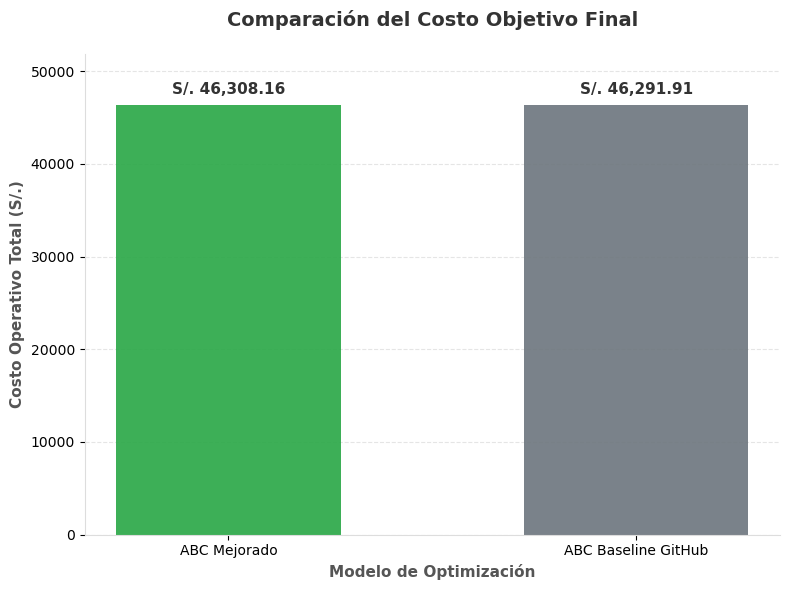

In [ ]:
#Grafica comparación costo objetivo final
fig, ax = plt.subplots(figsize=(8, 6))
colores = ['#28a745', '#6c757d'] 

bars = ax.bar(
    df_comparacion["Modelo"],
    df_comparacion["Objetivo metodología actual"],
    color=colores,
    width=0.55,
    alpha=0.9
)

ax.set_title("Comparación del Costo Objetivo Final", fontsize=14, fontweight='bold', pad=20, color='#333333')
ax.set_ylabel("Costo Operativo Total (S/.)", fontsize=11, fontweight='bold', color='#555555')
ax.set_xlabel("Modelo de Optimización", fontsize=11, fontweight='bold', color='#555555')

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        yval + (yval * 0.02),
        f"S/. {yval:,.2f}", 
        ha="center", 
        va="bottom", 
        fontsize=11, 
        fontweight='bold', 
        color='#333333'
    )

ax.grid(axis="y", linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')

ax.set_ylim(0, max(df_comparacion["Objetivo metodología actual"]) * 1.12)

plt.tight_layout()
plt.show()

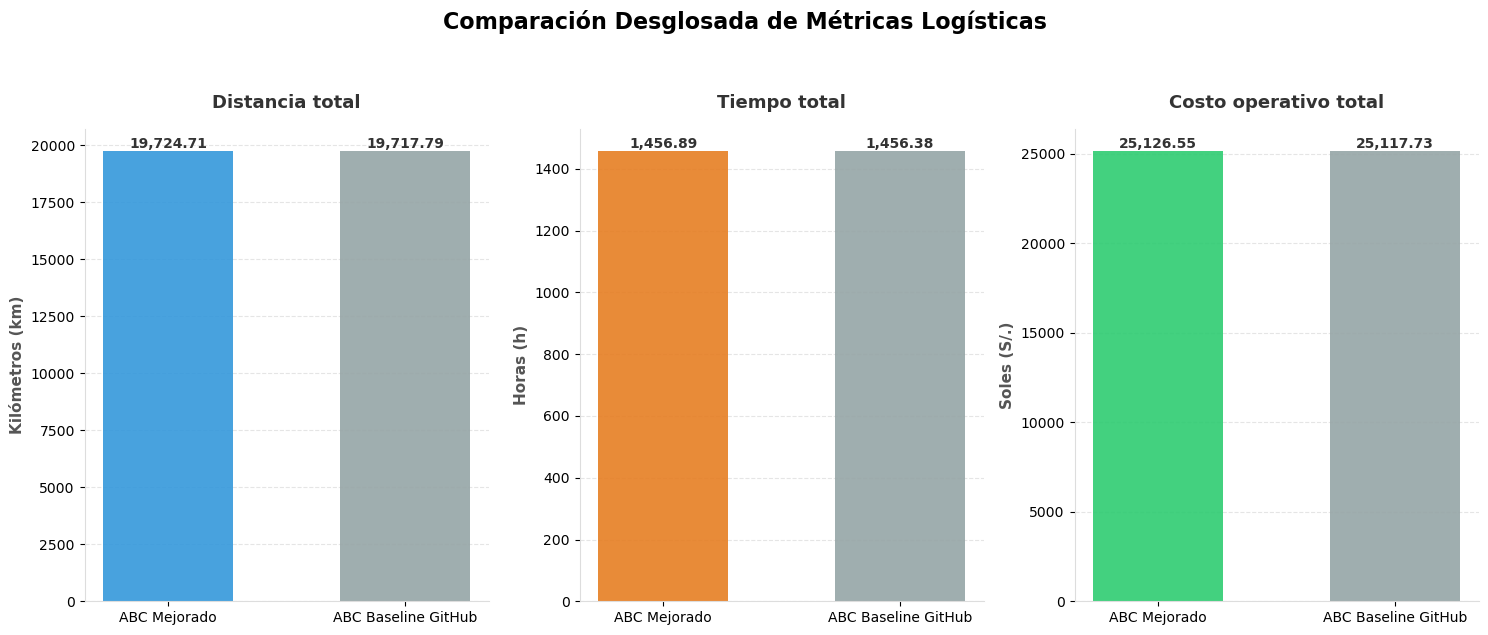

In [ ]:
#Graficos de Comparación Desglosada de Métricas Logísticas
metricas_a_comparar = [
    "Distancia total",
    "Tiempo total",
    "Costo operativo total"
]

unidades = {
    "Distancia total": "Kilómetros (km)",
    "Tiempo total": "Horas (h)",
    "Costo operativo total": "Soles (S/.)"
}

colores_metricas = ['#3498db', '#e67e22', '#2ecc71'] 
color_baseline = '#95a5a6'

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, metrica in enumerate(metricas_a_comparar):
    ax = axes[i]
    
    valores = df_comparacion[metrica]
    
    bars = ax.bar(
        df_comparacion["Modelo"], 
        valores, 
        color=[colores_metricas[i], color_baseline],
        width=0.55,
        alpha=0.9
    )
    
    ax.set_title(metrica, fontsize=13, fontweight='bold', pad=15, color='#333333')
    ax.set_ylabel(unidades[metrica], fontsize=11, fontweight='bold', color='#555555')
    
    ax.grid(axis="y", linestyle='--', alpha=0.5, color='#cccccc')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#dddddd')
    ax.spines['bottom'].set_color('#dddddd')
    
    for bar in bars:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            yval, 
            f"{yval:,.2f}", 
            ha="center", 
            va="bottom", 
            fontsize=10, 
            fontweight='bold', 
            color='#333333'
        )

plt.suptitle("Comparación Desglosada de Métricas Logísticas", fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

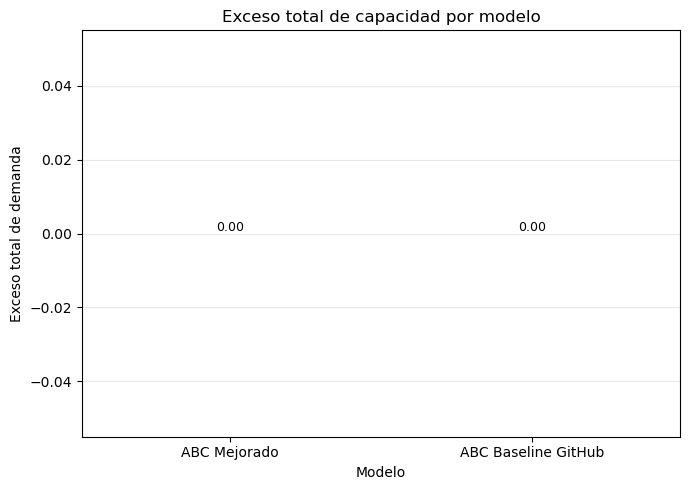

In [146]:
#Gráfico de exceso de capacidad:
plt.figure(figsize=(7, 5))

ax = plt.bar(
    df_comparacion["Modelo"],
    df_comparacion["Exceso total capacidad"]
)

plt.title("Exceso total de capacidad por modelo")
plt.ylabel("Exceso total de demanda")
plt.xlabel("Modelo")
plt.grid(axis="y", alpha=0.3)

for barra in ax:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

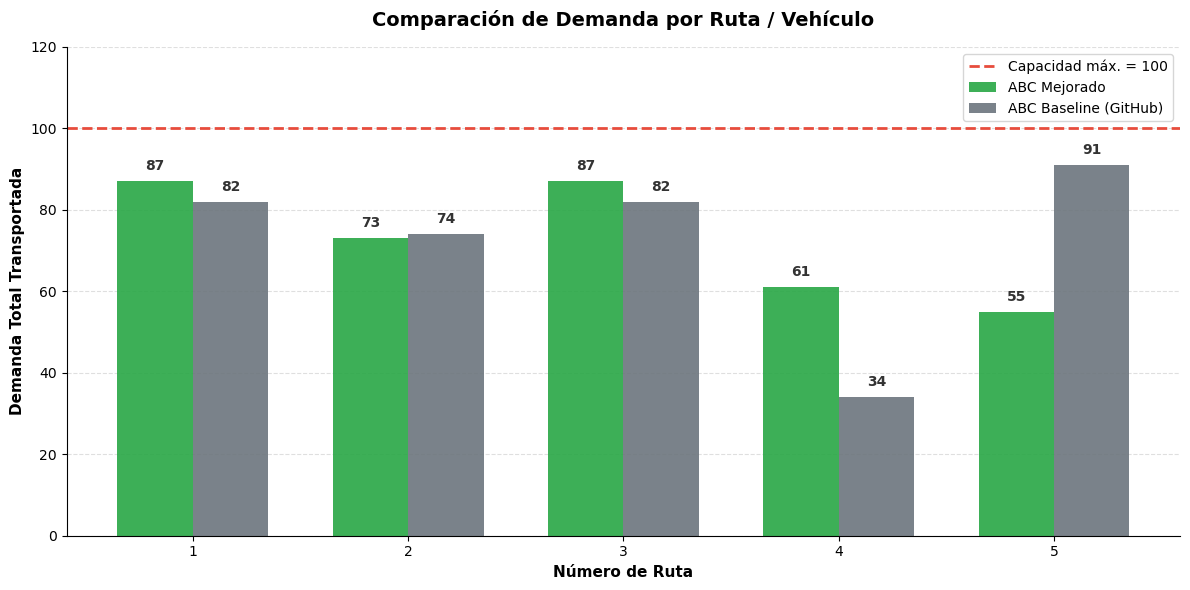

In [ ]:
#Gráfico de Comparación de Demanda por Ruta / Vehículo
demandas_mejorado = metricas_mejorado["demandas_ruta"]
demandas_baseline = metricas_baseline["demandas_ruta"]
capacidad = problema["capacity"]

max_rutas = max(len(demandas_mejorado), len(demandas_baseline))
dem_mej = demandas_mejorado + [0] * (max_rutas - len(demandas_mejorado))
dem_base = demandas_baseline + [0] * (max_rutas - len(demandas_baseline))

x = np.arange(1, max_rutas + 1)
ancho = 0.35 

fig, ax = plt.subplots(figsize=(12, 6))

barras_mejorado = ax.bar(x - ancho/2, dem_mej, ancho, label='ABC Mejorado', color='#28a745', alpha=0.9)
barras_baseline = ax.bar(x + ancho/2, dem_base, ancho, label='ABC Baseline (GitHub)', color='#6c757d', alpha=0.9)

ax.axhline(capacidad, color='#e74c3c', linestyle="--", linewidth=2, label=f"Capacidad máx. = {capacidad}")

ax.set_title("Comparación de Demanda por Ruta / Vehículo", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Número de Ruta", fontsize=11, fontweight='bold')
ax.set_ylabel("Demanda Total Transportada", fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.legend(loc='upper right')

ax.grid(axis="y", linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

def agregar_etiquetas(barras):
    for barra in barras:
        altura = barra.get_height()
        if altura > 0: 
            ax.text(
                barra.get_x() + barra.get_width()/2, 
                altura + (capacidad * 0.02),
                f"{altura:.0f}", 
                ha="center", 
                va="bottom", 
                fontsize=10,
                fontweight='bold',
                color='#333333'
            )

agregar_etiquetas(barras_mejorado)
agregar_etiquetas(barras_baseline)

ax.set_ylim(0, max(max(dem_mej), max(dem_base), capacidad) * 1.20)

plt.tight_layout()
plt.show()